In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\abdil\Downloads\netflix_titles.csv", encoding="latin-1")
print(df.shape)
print(df.columns.tolist())

(8807, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [7]:
print(df[['description', 'listed_in', 'rating', 'type']].isnull().sum())

description    0
listed_in      0
rating         4
type           0
dtype: int64


In [8]:
df['rating'] = df['rating'].fillna("Unknown")

In [9]:
print(df[['description', 'listed_in', 'rating', 'type']].isnull().sum())

description    0
listed_in      0
rating         0
type           0
dtype: int64


In [10]:
df["content"] = df["description"] + " " + df["listed_in"]

In [11]:
print(df["content"].head(2))

0    As her father nears the end of his life, filmm...
1    After crossing paths at a party, a Cape Town t...
Name: content, dtype: object


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:
tfid = TfidfVectorizer()
tfid_matrix = tfid.fit_transform(df["content"])

tfid_matrix.shape

In [18]:
from sklearn.cluster import KMeans

In [19]:
print(df['listed_in'].unique())

['Documentaries' 'International TV Shows, TV Dramas, TV Mysteries'
 'Crime TV Shows, International TV Shows, TV Action & Adventure'
 'Docuseries, Reality TV'
 'International TV Shows, Romantic TV Shows, TV Comedies'
 'TV Dramas, TV Horror, TV Mysteries' 'Children & Family Movies'
 'Dramas, Independent Movies, International Movies'
 'British TV Shows, Reality TV' 'Comedies, Dramas'
 'Crime TV Shows, Docuseries, International TV Shows'
 'Dramas, International Movies' 'Children & Family Movies, Comedies'
 'British TV Shows, Crime TV Shows, Docuseries' 'TV Comedies, TV Dramas'
 'Documentaries, International Movies'
 'Crime TV Shows, Spanish-Language TV Shows, TV Dramas' 'Thrillers'
 'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure'
 'International TV Shows, TV Action & Adventure, TV Dramas'
 'Comedies, International Movies'
 'Comedies, International Movies, Romantic Movies'
 'Docuseries, International TV Shows, Reality TV'
 'Comedies, International Movies, Music & 

In [20]:
km = KMeans(n_clusters=15)
km.fit(tfid_matrix)

,n_clusters,15
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [21]:
df['cluster'] = km.labels_

In [22]:
print(df['cluster'].value_counts())

cluster
10    1162
2      871
12     713
5      711
11     687
0      634
9      616
7      549
1      541
8      448
13     425
4      397
14     387
3      344
6      322
Name: count, dtype: int64


In [23]:
print(df[df['cluster'] == 0][['title', 'listed_in', 'description']].head(10))

                                                title  \
36                                     The Stronghold   
38                                Birth of the Dragon   
41                                               Jaws   
43                                             Jaws 3   
44                                  Jaws: The Revenge   
46                                         Safe House   
51  InuYasha the Movie 2: The Castle Beyond the Lo...   
52  InuYasha the Movie 3: Swords of an Honorable R...   
53    InuYasha the Movie 4: Fire on the Mystic Island   
54  InuYasha the Movie: Affections Touching Across...   

                                            listed_in  \
36   Action & Adventure, Dramas, International Movies   
38                         Action & Adventure, Dramas   
41         Action & Adventure, Classic Movies, Dramas   
43       Action & Adventure, Horror Movies, Thrillers   
44       Action & Adventure, Horror Movies, Thrillers   
46                            

In [24]:
print(df[df['cluster'] == 0]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
Action & Adventure       621
International Movies     317
Dramas                   190
Comedies                 136
Anime Features            41
Independent Movies        28
Classic Movies            26
Horror Movies             15
Cult Movies               15
TV Action & Adventure     10
Name: count, dtype: int64


In [25]:
print(df[df['cluster'] == 10]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
Dramas                  739
International Movies    632
Comedies                308
Independent Movies      244
Thrillers               197
Romantic Movies         150
Horror Movies           123
Movies                   36
Sports Movies            30
Classic Movies           27
Name: count, dtype: int64


In [26]:
print(df[df['cluster'] == 14]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
International Movies    225
Dramas                  196
Comedies                170
Romantic Movies          75
Independent Movies       59
Thrillers                56
Action & Adventure       28
Horror Movies            15
TV Comedies              10
Sports Movies            10
Name: count, dtype: int64


In [28]:
tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])
print(tfid_matrix.shape)

(8807, 19162)


In [29]:
df['listed_in'] = df['listed_in'].str.replace("International Movies", "")

In [30]:
df['listed_in'] = df['listed_in'].str.replace("TV Comedies", "Comedies")
df['listed_in'] = df['listed_in'].str.replace("TV Dramas", "Dramas")
df['listed_in'] = df['listed_in'].str.replace("TV Thrillers", "Thrillers")
df['listed_in'] = df['listed_in'].str.replace("TV Action & Adventure", "Action & Adventure")

In [31]:
df['content'] = df['description'] + " " + df['listed_in']

tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])

km = KMeans(n_clusters=15, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
0     1166
13    1142
2      920
11     827
3      720
9      654
8      575
4      536
12     463
6      453
7      397
14     371
5      343
10     124
1      116
Name: count, dtype: int64


In [32]:
print(df[df['cluster'] == 10]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
TV Mysteries              98
Dramas                    80
International TV Shows    55
TV Horror                 43
Crime TV Shows            29
TV Sci-Fi & Fantasy       18
Thrillers                  9
Action & Adventure         7
Teen TV Shows              7
Docuseries                 4
Name: count, dtype: int64


In [33]:
df['listed_in'] = df['listed_in'].str.replace(r'TV (Comedies|Dramas|Thrillers|Mysteries|Horror|Action & Adventure|Sci-Fi & Fantasy|Romance)', r'\1', regex=True)

In [34]:
df['content'] = df['description'] + " " + df['listed_in']

tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])

km = KMeans(n_clusters=15, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
7     1569
5     1255
8      828
14     767
10     586
6      577
2      574
0      501
4      454
11     397
12     355
3      347
13     328
1      211
9       58
Name: count, dtype: int64


In [35]:
print(df[df['cluster'] == 10]['listed_in'].str.split(', ').explode().value_counts().head(10))

listed_in
Documentaries               582
                            191
LGBTQ Movies                 25
Faith & Spirituality         10
Classic Movies               10
Children & Family Movies      4
Comedies                      3
Dramas                        3
Horror Movies                 2
TV Shows                      1
Name: count, dtype: int64


In [36]:
for i in range(15):
    top_genre = df[df['cluster'] == i]['listed_in'].str.split(', ').explode().value_counts().index[0]
    size = len(df[df['cluster'] == i])
    print(f"Cluster {i}: {top_genre} ({size} titles)")

Cluster 0: Thrillers (501 titles)
Cluster 1: Sports Movies (211 titles)
Cluster 2: Children & Family Movies (574 titles)
Cluster 3: Docuseries (347 titles)
Cluster 4: Kids' TV (454 titles)
Cluster 5: International TV Shows (1255 titles)
Cluster 6: Romantic Movies (577 titles)
Cluster 7: Dramas (1569 titles)
Cluster 8: Independent Movies (828 titles)
Cluster 9: Documentaries (58 titles)
Cluster 10: Documentaries (586 titles)
Cluster 11: Stand-Up Comedy (397 titles)
Cluster 12: Music & Musicals (355 titles)
Cluster 13: Sci-Fi & Fantasy (328 titles)
Cluster 14: Action & Adventure (767 titles)


In [37]:
df['listed_in'] = df['listed_in'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [38]:
df['content'] = df['description'] + " " + df['listed_in']

tfid = TfidfVectorizer(stop_words='english')
tfid_matrix = tfid.fit_transform(df['content'])

km = KMeans(n_clusters=15, random_state=42)
km.fit(tfid_matrix)

df['cluster'] = km.labels_
print(df['cluster'].value_counts())

cluster
7     1569
5     1255
8      828
14     767
10     586
6      577
2      574
0      501
4      454
11     397
12     355
3      347
13     328
1      211
9       58
Name: count, dtype: int64


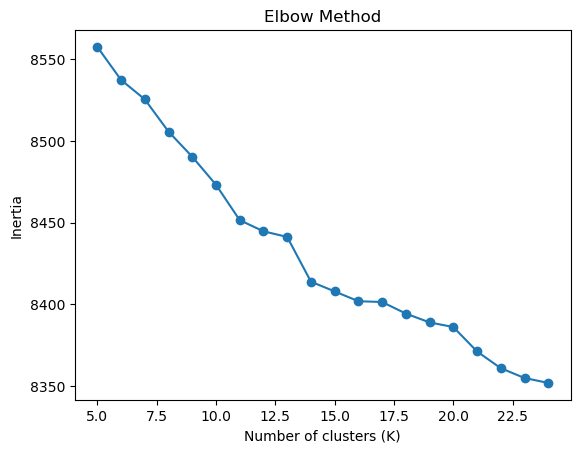

In [39]:
inertias = []
k_range = range(5, 25)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42)
    km_temp.fit(tfid_matrix)
    inertias.append(km_temp.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()